# 06 — Validation ที่เชื่อถือได้ + จุดตัดที่ mentor โทรไหว

บท 05 เราได้โมเดลแรกกับคะแนน AP มาแล้ว แต่คำถามที่แพงที่สุดใน ML ไม่ใช่
"คะแนนเท่าไร" — มันคือ **"เชื่อคะแนนนั้นได้แค่ไหน?"** เพราะเดือน ก.ย. นี้
เราจะเอาโมเดลไปชี้ว่า mentor ควรโทรหาใคร ถ้าคะแนนที่วัดมาเป็นภาพลวง
คนที่เจ็บคือเด็กที่ควรได้รับสายแต่ไม่ได้รับ

**สิ่งที่จะได้จากบทนี้ (~90 นาที):**
1. เข้าใจว่าทำไม **random split โกหก** กับข้อมูลแบบเรา (เล็ก + แถวไม่อิสระ + มีเวลาไหล)
2. วัดผลแบบ **expanding window** — replay อดีตเดือนต่อเดือน เหมือนใช้งานจริงทุกประการ
3. จัดศึก **LogReg vs challenger (HistGradientBoosting)** อย่างแฟร์
4. **Bootstrap CI** — รู้ว่าตัวเลขของเรา บวก/ลบ ได้แค่ไหน (บทเรียนความถ่อมตัว)
5. เลือก **threshold** ที่ mentor โทรไหวจริง (~30 สาย/เดือน)
6. เช็คความไวต่อ **label ที่ไม่ชัวร์** แล้ว **เซฟโมเดลจริง** ลง `models/churn_model.joblib`
   ให้บท 07–08 ใช้ต่อ

In [1]:
import os; os.environ.setdefault("ML_CHURN_DATA", "sample")  # repo สาธารณะรันบนข้อมูลสังเคราะห์ (โปรเจกต์ภายในตั้ง =real)
import sys; sys.path.insert(0, "..")
import pandas as pd
from src import checks, churn_utils, contracts
from src.config import DATA_DIR, IS_SAMPLE
plt = churn_utils.plot_style()
print("โหมดข้อมูล:", "SAMPLE (ข้อมูลจำลอง)" if IS_SAMPLE else f"REAL ({DATA_DIR})")

โหมดข้อมูล: SAMPLE (ข้อมูลจำลอง)


In [2]:
import numpy as np

# โหลดวัตถุดิบ แล้วสร้างตาราง features จากครัวกลาง (สูตร canonical เดียวกับบท 04)
read = lambda name, dates=(): pd.read_csv(DATA_DIR / f"{name}.csv", parse_dates=list(dates))
students   = read("students", ["signup_date"])
attendance = read("attendance_long", ["ep_final_date", "week_start"])
attempts   = read("exam_attempts", ["submitted_at"])
weekly     = read("weekly_metrics", ["week_start", "week_end"])
labels     = pd.read_csv(DATA_DIR / "labels_monthly.csv", dtype={"month": str}, parse_dates=["churn_date"])

feats = churn_utils.build_features_monthly(labels, attendance, attempts, weekly, students)

# แถวที่ใช้ train/วัดผลได้ = แถวที่มี label (ตัด NaN = censored ออก)
labeled = feats.dropna(subset=["churned_next_month"]).reset_index(drop=True)
# ตัด 103 คู่ (คน, เดือน) กำกวมออก — CEO ตัดสิน 11 ส.ค. 2026 (docs/data-dictionary.md)
_excl_path = DATA_DIR.parent / "raw" / "labels" / "exclude_pairs_2569.csv"
_excl = (pd.read_csv(_excl_path, dtype={"month": str}) if _excl_path.exists()
         else pd.DataFrame(columns=["student_key", "month"]))  # sample: ไม่มีคู่กำกวมให้ตัด
labeled = (labeled.merge(_excl[["student_key", "month"]], on=["student_key", "month"], how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge").reset_index(drop=True))
# ตัดนักเรียนสายเทป 29 คนออกจาก scope โมเดล — CEO ยืนยันรายชื่อ 29 ส.ค. 2026 (แยกไปเลนดูแลต่างหาก)
_replay_path = DATA_DIR.parent / "raw" / "labels" / "replay_students_2569.csv"
_replay = set(pd.read_csv(_replay_path)["student_key"]) if _replay_path.exists() else set()  # sample: ไม่มีสายเทป
_b = len(labeled)
labeled = labeled[~labeled["student_key"].isin(_replay)].reset_index(drop=True)
print(f"ตัดสายเทป {_b - len(labeled)} แถว → เหลือ {len(labeled)} แถว")
print(f"features ทั้งหมด {feats.shape} | มี label ใช้ได้ {len(labeled):,} แถว | "
      f"churn {int(labeled['churned_next_month'].sum())} ครั้ง "
      f"({labeled['churned_next_month'].mean():.1%})")

ตัดสายเทป 0 แถว → เหลือ 1333 แถว
features ทั้งหมด (1610, 20) | มี label ใช้ได้ 1,333 แถว | churn 117 ครั้ง (8.8%)


## ข้อมูลของเรามี "3 โรคประจำตัว" — และ random split แพ้ทั้ง 3 โรค

ก่อนเชื่อคะแนนไหนก็ตาม ต้องรู้จักคนไข้ก่อนครับ ข้อมูลเรามีอาการ 3 อย่าง:

| โรค | อาการ | ผลข้างเคียงตอนวัดผล |
|---|---|---|
| **1. เล็ก** | มี label แค่ ~1,333 แถว churn จริงแค่ **117 ครั้ง** | แบ่ง test ที 20% เหลือ churn ~23 ครั้ง — สุ่มโชคดี/ร้ายทีเดียว คะแนนแกว่งแรง |
| **2. แถวไม่อิสระ** | เด็ก 1 คนโผล่ 4–5 แถว (เดือนละแถว) นิสัยเดิมทุกแถว | สุ่มแบ่งแล้วเด็กคนเดียวกันไปอยู่ทั้ง train และ test — โมเดล "จำเด็กได้" ไม่ใช่ "เข้าใจ pattern" |
| **3. เวลาไหลไปข้างหน้า** | ของจริงคือ train จากอดีต → ทำนายเดือนที่ยังไม่เกิด | random split เอาอนาคตมาสอน เอาอดีตมาสอบ — สอบแบบนี้ไม่มีจริงในโลก |

single random split (แบบที่ตำราส่วนใหญ่เริ่ม) ตอบคำถามผิดข้อ:
มันตอบ *"โมเดลจำข้อมูลก้อนนี้ได้ดีไหม"* แต่คำถามธุรกิจเราคือ
*"สิ้นเดือนหน้า โมเดลจะชี้เด็กเสี่ยงถูกคนไหม"* — ลองดูหลักฐานกันครับ

In [3]:
# เครื่องมือประจำบท: โรงงานสร้างโมเดล 2 สูตร (จะได้ fit ใหม่กี่รอบก็สูตรเดิมเป๊ะ)
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

NUM, CAT = churn_utils.NUMERIC_FEATURES, churn_utils.CATEGORICAL_FEATURES
X_COLS = NUM + CAT

def make_logreg():
    # แชมป์เก่าจากบท 05 — สูตรเดิมเป๊ะ: impute median + scale + one-hot + LogReg
    prep = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
    ])
    return Pipeline([("prep", prep),
                     ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])

def make_hgb():
    # ผู้ท้าชิง — gradient boosting แบบต้นไม้: ไม่ต้อง scale ไม่ต้อง impute (กิน NaN ได้เลย)
    # หมายเหตุข้อมูลจริง: ปี 68 คอลัมน์ practice ว่างทั้งปี — HGB binning พังถ้า passthrough
    # จึงอุดรูด้วย median (keep_empty_features กันคอลัมน์ว่างล้วนหาย)
    prep = ColumnTransformer([
        ("num", SimpleImputer(strategy="median", keep_empty_features=True), NUM),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT),
    ])
    return Pipeline([("prep", prep),
                     ("clf", HistGradientBoostingClassifier(random_state=42,
                                                            class_weight="balanced"))])

print(f"พร้อม: {len(NUM)} numeric + {len(CAT)} categorical features")

พร้อม: 13 numeric + 3 categorical features


In [4]:
# หลักฐานคาตา: random split เดิมๆ 3 ครั้ง (เปลี่ยนแค่ seed) — คะแนนแกว่งแค่ไหน?
from sklearn.model_selection import train_test_split

for seed in [0, 1, 42]:
    tr, te = train_test_split(labeled, test_size=0.2, random_state=seed,
                              stratify=labeled["churned_next_month"])
    p = make_logreg().fit(tr[X_COLS], tr["churned_next_month"]).predict_proba(te[X_COLS])[:, 1]
    ap = average_precision_score(te["churned_next_month"], p)
    overlap = te["student_key"].isin(set(tr["student_key"])).mean()
    print(f"seed {seed:2d}: AP = {ap:.3f} | {overlap:.0%} ของแถว test มีเด็กคนเดียวกันอยู่ใน train")

seed  0: AP = 0.239 | 97% ของแถว test มีเด็กคนเดียวกันอยู่ใน train
seed  1: AP = 0.232 | 96% ของแถว test มีเด็กคนเดียวกันอยู่ใน train
seed 42: AP = 0.304 | 97% ของแถว test มีเด็กคนเดียวกันอยู่ใน train


เห็นไหมครับ — **เปลี่ยนแค่ seed คะแนนก็วิ่งจาก 0.23 ไป 0.30** (โรคข้อ 1)
แถม ~97% ของแถว test มีเด็กคนเดิมแอบอยู่ฝั่ง train (โรคข้อ 2) และทุกรอบ
โมเดลได้เห็นเดือนอนาคตตอน train (โรคข้อ 3) — ตัวเลขจาก split แบบนี้
เอาไปคุยกับทีมไม่ได้เลย เพราะถามใหม่ได้คำตอบใหม่ทุกครั้ง

ยารักษาของเราชื่อ **expanding window** ครับ — ไปดูกัน

## [แนวคิด] 6.1 Expanding window — replay อดีตเหมือนอยู่ในเหตุการณ์จริง

หลักคิดง่ายกว่าชื่อมาก: **ย้อนเวลากลับไปยืนตรงสิ้นเดือนนั้นจริงๆ แล้วสอบโมเดล
แบบเดียวกับที่มันจะโดนใช้งาน** เดือนต่อเดือน:

```text
ยกที่ 1: train ด้วยเดือน มี.ค.–เม.ย. 68  → สอบกับเดือน พ.ค. 68
ยกที่ 2: train ด้วย มี.ค.–พ.ค. 68        → สอบกับ มิ.ย. 68
   ...หน้าต่าง train ขยายไปเรื่อยๆ (จึงชื่อ expanding)...
ยกที่ 9: train ด้วยทุกเดือนถึง มิ.ย. 69   → สอบกับ ก.ค. 69
```

แก้ครบทั้ง 3 โรค: ไม่มีเดือนอนาคตหลุดเข้า train (โรค 3) · เด็กใน test เดือนนั้น
ต่อให้เคยอยู่ใน train ก็เป็น "ข้อมูลเก่าของเขา" ที่เรารู้จริง ณ เวลานั้น (โรค 2
แบบที่ตรงกับการใช้งานจริง) · และได้คะแนน **หลายยก** มาดูการแกว่ง แทนที่จะได้
เลขเดียวแบบหลอกๆ (โรค 1) — สองเดือนแรกไม่สอบเพราะ train ยังน้อยเกิน
(`min_train_months=2`)

เดือนของเราเป็น string "YYYY-MM" ซึ่ง**เรียงตามตัวอักษร = เรียงตามเวลา**พอดี
เพราะงั้นเงื่อนไข `month < m` ใช้ได้ตรงๆ เลยครับ

In [5]:
# ตัวอย่าง (เคสคู่ขนาน): panel จิ๋วแต่งเอง — ดูกลไก loop เปล่าๆ ก่อน ไม่มีโมเดล
toy = pd.DataFrame({
    "month":   ["2025-03", "2025-03", "2025-04", "2025-04", "2025-05", "2025-05", "2025-06"],
    "student": ["A", "B", "A", "B", "A", "B", "B"],
})
toy_months = sorted(toy["month"].unique())          # เรียง string = เรียงเวลา
for m in toy_months[2:]:                            # ข้าม 2 เดือนแรก (train น้อยเกิน)
    train = toy[toy["month"] < m]
    test = toy[toy["month"] == m]
    print(f"test เดือน {m}: train {len(train)} แถว (เดือนก่อนหน้าทั้งหมด) | test {len(test)} แถว")


test เดือน 2025-05: train 4 แถว (เดือนก่อนหน้าทั้งหมด) | test 2 แถว
test เดือน 2025-06: train 6 แถว (เดือนก่อนหน้าทั้งหมด) | test 1 แถว


### [แบบฝึกหัด 6.1] สร้าง expanding window เองกับมือ แล้วเทียบกับของกลาง

ทำแบบเดียวกับตัวอย่าง แต่ใช้ **ตาราง `labeled` ของจริง** — เขียน loop เองก่อน
เพื่อให้มั่นใจว่าเราเข้าใจกลไก แล้วค่อยเทียบว่าตรงกับ
`churn_utils.expanding_window_splits` (ฟังก์ชันกลางที่บทนี้จะใช้ยาวๆ)

**คำสั่ง:**
1. `months = sorted(labeled["month"].unique())` (ให้ฟรีใน skeleton)
2. วนลูป `for m in months[2:]:` — ข้าม 2 เดือนแรกตามกติกา `min_train_months=2`
3. ในลูป: นับแถว train (`month < m`) และแถว test (`month == m`)
4. เก็บเป็น DataFrame ชื่อ `fold_table` มี 3 คอลัมน์: `test_month`, `n_train`, `n_test`
5. (พิสูจน์) สร้างตารางเดียวกันจาก `churn_utils.expanding_window_splits(labeled, "month", min_train_months=2)`
   แล้วเทียบว่าตรงกันทุกช่อง — generator คืน `(train_idx, test_idx, test_month)` ต่อยก

**ผลลัพธ์ที่คาด:** `(9, 3)` — ยกแรก test เดือน 2025-05 (train 234 / test 140)
ยกสุดท้าย 2026-07 (train 1,227 / test 106)

In [6]:
months = sorted(labeled["month"].unique())   # ให้ฟรี — 11 เดือนที่มี label
print(months)


['2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07']


In [7]:
months = sorted(labeled["month"].unique())   # ให้ฟรี — 11 เดือนที่มี label
print(months)

rows = []                                        # ตะกร้า
for m in months[2:]:                             # ข้าม 2 เดือนแรก (min_train_months=2)
    train = labeled[labeled["month"] < m]
    test = labeled[labeled["month"] == m]
    rows.append({"test_month": m, "n_train": len(train), "n_test": len(test)})

fold_table = pd.DataFrame(rows)
print(fold_table.to_string(index=False))

checks.check("ex_06_01", fold_table)


['2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07']
test_month  n_train  n_test
   2025-05      234     140
   2025-06      374     144
   2025-07      518     132
   2025-08      650     113
   2026-03      763     108
   2026-04      871     124
   2026-05      995     119
   2026-06     1114     113
   2026-07     1227     106


ผ่าน ✓  (ex_06_01) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

โครงเดียวกับ toy เป๊ะ แค่เปลี่ยนเป็นตารางจริง — ในลูปแต่ละเดือน นับขนาดก้อน train
(ทุกแถวที่เดือนมาก่อนเดือนสอบ) กับก้อน test (แถวของเดือนสอบเอง) เก็บผลเป็น dict
ต่อท้าย list ไว้ แล้วค่อยแปลงทั้ง list เป็นตารางทีเดียวตอนจบลูป · ฝั่งพิสูจน์
ก็สร้างตารางหน้าตาเดียวกันจาก generator ของกลาง โดยนับความยาวของ index
สองก้อนที่มันคืนมาในแต่ละยก แล้วเทียบสองตารางว่าเท่ากันทุกช่อง

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- นับขนาดก้อนด้วย `len(...)` · เก็บผลด้วย `.append({...})` แล้วแปลงเป็นตารางด้วย `pd.DataFrame([...])`
- ของกลาง: `churn_utils.expanding_window_splits(..., "month", min_train_months=2)`
  (generator — วนด้วย for ได้เลย)
- เทียบสองตาราง: `.equals(...)`

</details>

In [8]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_06_01.py

## [แนวคิด] 6.2 จัดศึก 9 ยก: แชมป์เก่า LogReg vs ผู้ท้าชิง HGB

คำถามที่ CEO สาย tech โดนถามบ่อยสุด: *"ทำไมไม่ใช้โมเดลเทพๆ ไปเลย?"*
วันนี้เราจะตอบด้วยการทดลอง ไม่ใช่ความเชื่อ — จับ **HistGradientBoostingClassifier**
(กลุ่มเดียวกับ XGBoost/LightGBM ที่ชนะการแข่ง Kaggle บ่อยๆ) มาชกกับ LogReg
ของเราภายใต้กติกาเดียวกัน: expanding window ทั้ง 9 ยก

ข้อแตกต่างที่ควรรู้ก่อนดูผล:

| | LogReg (แชมป์) | HGB (ผู้ท้าชิง) |
|---|---|---|
| ธรรมชาติ | เส้นตรง เรียบง่าย อธิบายง่าย | ต้นไม้หลายร้อยต้น จับ pattern ซับซ้อนได้ |
| เตรียมข้อมูล | ต้อง impute + scale + one-hot | กิน NaN ได้เลย ไม่ต้อง scale |
| จุดอ่อน | pattern โค้งๆ ซับซ้อนจับไม่ได้ | **data เล็กจะ overfit ง่าย** — จำ noise แทน pattern |

กติกาตัดสิน: **AP (Average Precision) รายยก + ค่าเฉลี่ย** — เกณฑ์เดียวกับบท 05
(เรียงเด็กเสี่ยงไว้หัวแถวได้ดีแค่ไหน · base rate ~0.088 = เดามั่ว)

In [9]:
# ตัวอย่าง (เคสคู่ขนาน): ชกโชว์ 1 ยกก่อน — ยกแรกสุด (test เดือน พ.ค. 68)
tr_idx, te_idx, m = next(churn_utils.expanding_window_splits(labeled, "month", min_train_months=2))
X_tr, y_tr = labeled.loc[tr_idx, X_COLS], labeled.loc[tr_idx, "churned_next_month"]
X_te, y_te = labeled.loc[te_idx, X_COLS], labeled.loc[te_idx, "churned_next_month"]

p_lr  = make_logreg().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
p_hgb = make_hgb().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
rows = []


print(f"ยกที่ 1 — test เดือน {m}: train {len(tr_idx)} แถว | test {len(te_idx)} แถว "
      f"(churn จริง {int(y_te.sum())} คน)")
print(f"AP: LogReg {average_precision_score(y_te, p_lr):.3f} | "
      f"HGB {average_precision_score(y_te, p_hgb):.3f}")
print("ยกเดียวสรุปไม่ได้ครับ — churn แค่ 5 คน แกว่งง่ายมาก ต้องดูให้ครบ 9 ยก")

ยกที่ 1 — test เดือน 2025-05: train 234 แถว | test 140 แถว (churn จริง 5 คน)
AP: LogReg 0.108 | HGB 0.062
ยกเดียวสรุปไม่ได้ครับ — churn แค่ 5 คน แกว่งง่ายมาก ต้องดูให้ครบ 9 ยก


### [แบบฝึกหัด 6.2] ชกให้ครบ 9 ยก — ตาราง AP รายเดือน + ค่าเฉลี่ย

สเกลจาก 1 ยก → ทั้ง 9 ยก (ใช้เวลารันราวๆ 5–10 วินาที ปล่อยมันทำงานครับ)

**คำสั่ง:**
1. วนลูป `churn_utils.expanding_window_splits(labeled, "month", min_train_months=2)`
2. ในแต่ละยก: fit ทั้ง `make_logreg()` และ `make_hgb()` ด้วย train ของยกนั้น
   แล้ววัด AP บน test ของยกนั้น (แบบเดียวกับตัวอย่างเป๊ะ)
3. เก็บเป็น DataFrame ชื่อ `duel` — 5 คอลัมน์: `test_month`, `n_test`,
   `churn_test` (จำนวน churn จริงในเดือน test), `ap_logreg`, `ap_hgb`
4. print ค่าเฉลี่ยของ `ap_logreg` และ `ap_hgb` ปิดท้าย — ใครชนะ?

**ผลลัพธ์ที่คาด:** `(9, 5)` — ยกแรก ap_logreg ≈ 0.108 / ap_hgb ≈ 0.073
และค่าเฉลี่ยห่างกันชัดพอสมควร

In [10]:
rows = []                                                        # ตะกร้า
for tr_idx, te_idx, m in churn_utils.expanding_window_splits(labeled, "month", min_train_months=2):
    # --- 4 บรรทัดนี้ของคุณถูกอยู่แล้ว ยกมาทั้งดุ้น แค่ย้ายเข้าลูป ---
    X_tr, y_tr = labeled.loc[tr_idx, X_COLS], labeled.loc[tr_idx, "churned_next_month"]
    X_te, y_te = labeled.loc[te_idx, X_COLS], labeled.loc[te_idx, "churned_next_month"]
    p_reg = make_logreg().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    p_hgb = make_hgb().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]

    rows.append({"test_month": m,                                # บัตรจดผลยกนี้ — 5 ช่องตามโจทย์
                 "n_test": len(te_idx),
                 "churn_test": int(y_te.sum()),                  # sum ของ 0/1 = นับตัวจริง (trick เดิม)
                 "ap_logreg": average_precision_score(y_te, p_reg),
                 "ap_hgb": average_precision_score(y_te, p_hgb)})

duel = pd.DataFrame(rows)                                        # เทตะกร้าเป็นตาราง 9 แถว
print(duel.round(3).to_string(index=False))
print("\nค่าเฉลี่ย:", duel[["ap_logreg", "ap_hgb"]].mean().round(3).to_dict())
checks.check("ex_06_02", duel)


test_month  n_test  churn_test  ap_logreg  ap_hgb
   2025-05     140           5      0.108   0.062
   2025-06     144          12      0.302   0.307
   2025-07     132          19      0.268   0.199
   2025-08     113          13      0.165   0.128
   2026-03     108          13      0.284   0.267
   2026-04     124          13      0.379   0.152
   2026-05     119          11      0.223   0.125
   2026-06     113           7      0.261   0.294
   2026-07     106          13      0.295   0.272

ค่าเฉลี่ย: {'ap_logreg': 0.254, 'ap_hgb': 0.201}


ผ่าน ✓  (ex_06_02) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

ยกโค้ดจาก cell ตัวอย่างมาใส่ในลูปได้เลย — เปลี่ยนจากการหยิบมาดูแค่ยกแรก
เป็นวนให้ครบทุกยกของ generator ตัวเดิม ในแต่ละยก fit ทั้งสองสูตรด้วย train
ของยกนั้นแล้ววัด AP บน test ของยกเดียวกัน เก็บผลเป็น dict ต่อท้าย list
จบลูปค่อยแปลงเป็นตาราง · จำนวน churn ในเดือน test คือผลรวมของ label
ฝั่ง test (label เป็นเลข 0/1 อยู่แล้ว บวกกันได้ตรงๆ)

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `churn_utils.expanding_window_splits(..., "month", min_train_months=2)`
- เลือกแถวตาม index ที่ generator คืน: `.loc[...]`
- `.fit(...)` · `.predict_proba(...)[:, 1]` · `average_precision_score(...)`
- จำนวน churn: `int(... .sum())` · ค่าเฉลี่ยปิดท้าย: `.mean()` ของสองคอลัมน์ AP

</details>

In [11]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_06_02.py

In [12]:
# checkpoint: ผลศึกฉบับ canonical + เก็บคำทำนาย out-of-fold (OOF) ไว้ใช้ต่อทั้งบท
# (OOF = คำทำนายของแต่ละเดือน จากโมเดลที่ "ไม่เคยเห็น" เดือนนั้นตอน train)
rows, oof_parts = [], []
for tr_idx, te_idx, m in churn_utils.expanding_window_splits(labeled, "month", min_train_months=2):
    X_tr, y_tr = labeled.loc[tr_idx, X_COLS], labeled.loc[tr_idx, "churned_next_month"]
    X_te, y_te = labeled.loc[te_idx, X_COLS], labeled.loc[te_idx, "churned_next_month"]
    p_lr  = make_logreg().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    p_hgb = make_hgb().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    rows.append({"test_month": m, "n_test": len(te_idx), "churn_test": int(y_te.sum()),
                 "ap_logreg": average_precision_score(y_te, p_lr),
                 "ap_hgb": average_precision_score(y_te, p_hgb)})
    oof_parts.append(pd.DataFrame({
        "student_key": labeled.loc[te_idx, "student_key"].values, "month": m,
        "y_true": y_te.values, "p_logreg": p_lr, "p_hgb": p_hgb}))

duel_ok = pd.DataFrame(rows)
oof = pd.concat(oof_parts, ignore_index=True)
oof["p_model"] = oof["p_logreg"]                       # ผู้ชนะของเรา = แชมป์เก่า LogReg
oof69 = oof[oof["month"] >= "2026-03"].reset_index(drop=True)   # เฉพาะซีซันปี 69

print(duel_ok.round(3).to_string(index=False))
print(f"\nAP เฉลี่ย 9 ยก: LogReg {duel_ok['ap_logreg'].mean():.3f} | "
      f"HGB {duel_ok['ap_hgb'].mean():.3f}  → แชมป์เก่าป้องกันแชมป์สำเร็จ")
print(f"OOF เก็บไว้ {len(oof):,} แถว | เฉพาะปี 69: {len(oof69)} แถว "
      f"({int(oof69['y_true'].sum())} churns)")

test_month  n_test  churn_test  ap_logreg  ap_hgb
   2025-05     140           5      0.108   0.062
   2025-06     144          12      0.302   0.307
   2025-07     132          19      0.268   0.199
   2025-08     113          13      0.165   0.128
   2026-03     108          13      0.284   0.267
   2026-04     124          13      0.379   0.152
   2026-05     119          11      0.223   0.125
   2026-06     113           7      0.261   0.294
   2026-07     106          13      0.295   0.272

AP เฉลี่ย 9 ยก: LogReg 0.254 | HGB 0.201  → แชมป์เก่าป้องกันแชมป์สำเร็จ
OOF เก็บไว้ 1,099 แถว | เฉพาะปี 69: 570 แถว (57 churns)


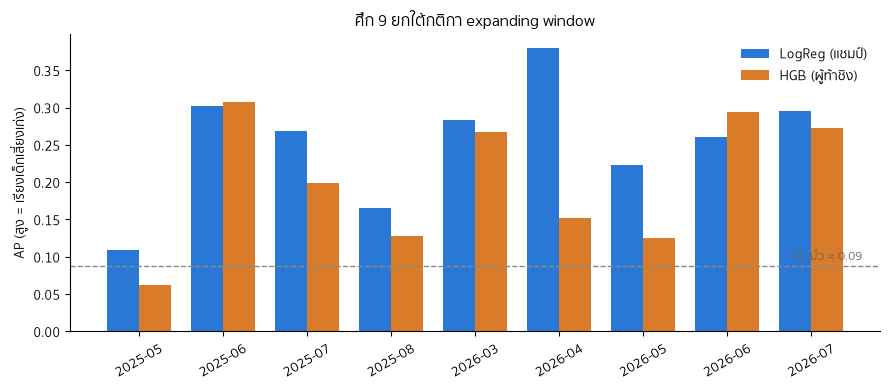

In [13]:
# ภาพเดียวจบ: AP รายยก — LogReg นำเกือบทุกเดือน (HGB แซงได้แค่ 1–2 เดือนจาก 9)
x = np.arange(len(duel_ok)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, duel_ok["ap_logreg"], w, label="LogReg (แชมป์)", color="#2a78d6")
ax.bar(x + w/2, duel_ok["ap_hgb"], w, label="HGB (ผู้ท้าชิง)", color="#d97b29")
base = labeled["churned_next_month"].mean()
ax.axhline(base, color="#888888", lw=1, ls="--")
ax.text(len(duel_ok) - 0.4, base + 0.008, f"เดามั่ว ≈ {base:.2f}", color="#666666",
        ha="right", fontsize=9)
ax.set_xticks(x, duel_ok["test_month"], rotation=30)
ax.set_ylabel("AP (สูง = เรียงเด็กเสี่ยงเก่ง)")
ax.set_title("ศึก 9 ยกใต้กติกา expanding window")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**บทเรียนสำคัญของยุคนี้:** โมเดลที่ซับซ้อนกว่า *ไม่ได้* แปลว่าดีกว่า —
กับ data 1,333 แถว / churn 117 ครั้ง ต้นไม้หลายร้อยต้นของ HGB มีอิสระมากพอจะ
**จำ noise** แทนที่จะเรียน pattern ส่วน LogReg ที่จืดชืดกลับนิ่งกว่าเพราะมัน
"จำอะไรมากไม่ได้" โดยธรรมชาติ — ความจืดคือเกราะกับ data เล็ก
(ธุรกิจส่วนใหญ่ในโลกจริงก็ data ประมาณเรานี่แหละครับ ไม่ใช่ระดับ Google)

แถมโบนัสฝั่งเรา: LogReg อธิบายรายคนได้ง่าย (บท 07 ทั้งบทพึ่งสิ่งนี้)
ในขณะที่ HGB อธิบายยากกว่ามาก — แพ้ทั้งคะแนน แพ้ทั้งความโปร่งใส เก็บกระเป๋ากลับบ้านครับ

> ⚠️ **กับดัก! ถ้าวันหนึ่งจะ tune hyperparameter — ต้องใช้ GroupKFold by student**
> การ tune (เช่นหา `C` ของ LogReg หรือ `max_depth` ของ HGB) ต้องแบ่ง train/validation
> *ภายใน* ข้อมูล train อีกชั้น ถ้าใช้ KFold สุ่มธรรมดา **เด็กคนเดียวกันจะไปอยู่ทั้งสองฝั่ง**
> (โรคข้อ 2 กลับมาอีกแล้ว!) — ค่า hyperparameter ที่ "ชนะ" จะเป็นตัวที่เก่งเรื่องจำเด็ก
> ไม่ใช่ตัวที่ generalize เก่ง · ทางแก้: `GroupKFold(groups=student_key)`
> บังคับให้เด็ก 1 คนอยู่ฝั่งเดียวเท่านั้น — ดูหลักฐานใน cell ล่าง

In [14]:
# หลักฐานสั้นๆ: KFold สุ่ม vs GroupKFold — เด็กรั่วข้ามฝั่งแค่ไหน?
from sklearn.model_selection import GroupKFold, KFold

tr_i, va_i = next(KFold(n_splits=5, shuffle=True, random_state=42).split(labeled))
leak = labeled.iloc[va_i]["student_key"].isin(set(labeled.iloc[tr_i]["student_key"])).mean()

tr_g, va_g = next(GroupKFold(n_splits=5).split(labeled, groups=labeled["student_key"]))
leak_g = labeled.iloc[va_g]["student_key"].isin(set(labeled.iloc[tr_g]["student_key"])).mean()

print(f"KFold สุ่มธรรมดา : {leak:.0%} ของแถว validation มีเด็กคนเดียวกันอยู่ฝั่ง train — ข้อสอบรั่ว!")
print(f"GroupKFold       : {leak_g:.0%} — เด็กหนึ่งคนอยู่ฝั่งเดียวเสมอ ปลอดภัย")
print("(บทนี้เราไม่ tune อะไร เลยไม่ได้ใช้ต่อ — แต่จำไว้ใช้วันที่อยาก tune ครับ)")

KFold สุ่มธรรมดา : 97% ของแถว validation มีเด็กคนเดียวกันอยู่ฝั่ง train — ข้อสอบรั่ว!
GroupKFold       : 0% — เด็กหนึ่งคนอยู่ฝั่งเดียวเสมอ ปลอดภัย
(บทนี้เราไม่ tune อะไร เลยไม่ได้ใช้ต่อ — แต่จำไว้ใช้วันที่อยาก tune ครับ)


## [แนวคิด] 6.3 Bootstrap CI — ตัวเลขเดียวคือคำโกหกครึ่งเดียว

"AP ของโมเดล = 0.245" ฟังดูมั่นใจดี แต่จำโรคข้อ 1 ได้ไหมครับ — คะแนนนี้วัดจาก
OOF ปี 69 ที่มี churn จริงแค่ **57 ครั้ง** ถ้าเหตุการณ์สุ่มต่างไปนิดเดียว
(เด็กสัก 3–4 คนตัดสินใจต่างไป) ตัวเลขก็ขยับแล้ว — แล้วมันขยับได้*แค่ไหน*?

**Bootstrap** ตอบด้วยวิธีบ้านๆ ที่เวิร์คมาก: สุ่มหยิบแถวจากข้อมูลเดิม *แบบใส่คืน*
ให้ได้ก้อนขนาดเท่าเดิม (บางแถวถูกหยิบซ้ำ บางแถวไม่ถูกหยิบ) → วัด AP ของก้อนนั้น →
ทำซ้ำ 1,000 รอบ → ได้ AP 1,000 ค่า → ตัดหัวตัดหาง 2.5% เหลือช่วงตรงกลาง 95%
คือ **confidence interval (CI)**: ช่วงที่ค่าจริงน่าจะอยู่

เรามี `churn_utils.bootstrap_ci(y_true, y_score, metric_fn)` ทำให้ครบแล้ว
คืน `(point, lo, hi)` — จุดประมาณ, ขอบล่าง, ขอบบน

In [15]:
# ตัวอย่าง (เคสคู่ขนาน): CI ของ "ผู้แพ้" HGB บน OOF ปี 69
pt, lo, hi = churn_utils.bootstrap_ci(oof69["y_true"], oof69["p_hgb"], average_precision_score)
print(f"AP ของ HGB = {pt:.3f}  |  95% CI ≈ [{lo:.3f}, {hi:.3f}]  (กว้าง {hi - lo:.3f})")
print(f"ฐานข้อมูลที่ใช้วัด: {len(oof69)} แถว แต่ churn จริงแค่ {int(oof69['y_true'].sum())} คน "
      "← ตัวการที่ทำให้ CI กว้าง")

AP ของ HGB = 0.188  |  95% CI ≈ [0.119, 0.296]  (กว้าง 0.177)
ฐานข้อมูลที่ใช้วัด: 570 แถว แต่ churn จริงแค่ 57 คน ← ตัวการที่ทำให้ CI กว้าง


### [แบบฝึกหัด 6.3] CI ของแชมป์ — แล้วอ่านมันให้เป็น

**คำสั่ง:**
1. เรียก `churn_utils.bootstrap_ci` กับ OOF ปี 69 ของ**ผู้ชนะ** (คอลัมน์ `p_model`
   ใน `oof69`) — metric คือ `average_precision_score` · อย่าเปลี่ยน argument อื่น
   (default: 1,000 รอบ, seed 42)
2. เก็บผลทั้ง tuple ใน `ci_ap` แล้วแตกเป็น `point, lo, hi` มา print ให้อ่านง่าย

**ผลลัพธ์ที่คาด:** point ≈ 0.245 และช่วงที่**กว้างจนต้องนั่งนิ่งๆ สักพัก** —
ขอบล่างกับขอบบนห่างกันราวๆ เท่าตัว

In [16]:
# TODO: bootstrap CI ของ AP ผู้ชนะ (p_model) บน oof69
point, lo, hi = churn_utils.bootstrap_ci(oof69["y_true"], oof69["p_model"], average_precision_score)
ci_ap = (point, lo, hi)
print(ci_ap)
checks.check("ex_06_03", ci_ap)

(0.24451964341071028, 0.16182915189727903, 0.360531828952898)


ผ่าน ✓  (ex_06_03) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

หน้าตาเหมือน cell ตัวอย่างเป๊ะ เปลี่ยนแค่คอลัมน์คะแนนจากของผู้แพ้เป็นของผู้ชนะ
— ฟังก์ชันคืนค่าเป็น tuple 3 ตัวตามลำดับ จุดประมาณ ขอบล่าง ขอบบน
จะรับทั้งก้อนไว้ในตัวแปรเดียวก่อน แล้วค่อยแตกออกเป็นสามค่าทีหลังตอน print ก็ได้

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `churn_utils.bootstrap_ci(..., average_precision_score)` — อย่าตั้ง argument อื่น
  (ปล่อย default: 1,000 รอบ, seed 42)
- ฟังก์ชันคืน tuple `(point, lo, hi)` — แตกค่าด้วย unpacking ปกติของ Python

</details>

In [17]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_06_03.py

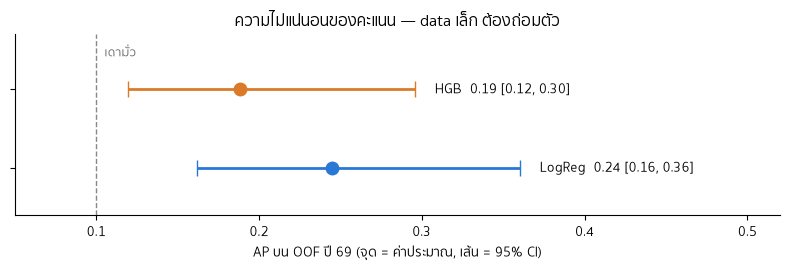

In [18]:
# เห็นภาพชัดกว่าตัวเลข: CI ของทั้งคู่ ซ้อนกันเป็นช่วงยาวเหยียด
ci_lr_ok = churn_utils.bootstrap_ci(oof69["y_true"], oof69["p_logreg"], average_precision_score)
ci_hgb_ok = churn_utils.bootstrap_ci(oof69["y_true"], oof69["p_hgb"], average_precision_score)

fig, ax = plt.subplots(figsize=(8, 2.8))
for i, (name, (pt, lo, hi), c) in enumerate([("LogReg", ci_lr_ok, "#2a78d6"),
                                             ("HGB", ci_hgb_ok, "#d97b29")]):
    ax.errorbar([pt], [i], xerr=[[pt - lo], [hi - pt]], fmt="o", color=c,
                capsize=6, lw=2, markersize=9)
    ax.text(hi + 0.012, i, f"{name}  {pt:.2f} [{lo:.2f}, {hi:.2f}]", va="center", fontsize=10)
ax.axvline(oof69["y_true"].mean(), color="#888888", ls="--", lw=1)
ax.text(oof69["y_true"].mean() + 0.005, 1.42, "เดามั่ว", color="#666666", fontsize=9)
ax.set_yticks([0, 1], ["", ""]); ax.set_ylim(-0.6, 1.7); ax.set_xlim(0.05, 0.52)
ax.set_xlabel("AP บน OOF ปี 69 (จุด = ค่าประมาณ, เส้น = 95% CI)")
ax.set_title("ความไม่แน่นอนของคะแนน — data เล็ก ต้องถ่อมตัว")
plt.tight_layout(); plt.show()

**อ่าน CI ให้เป็น = วิชาความถ่อมตัวของคน data:**

- CI ของ LogReg ≈ [0.16, 0.36] — **กว้างเกือบเท่าตัว** สาเหตุเดียวเลย: churn 57 ครั้ง
  มันน้อยจริงๆ ไม่มีเทคนิคสถิติไหนเสกความแม่นจากข้อมูลที่ยังไม่มีได้
- CI สองโมเดล**ซ้อนกันเยอะ** — พูดตรงๆ คือเรายังไม่กล้าฟันธง 100% ว่า LogReg
  เก่งกว่า HGB "จริง" (แต่เลือก LogReg อยู่ดี: คะแนนเฉลี่ยนำทุกมุมมอง + อธิบายง่ายกว่า)
- ที่กล้าพูดเต็มปาก: **ขอบล่าง 0.16 ยังสูงกว่าเดามั่ว (0.10)** — ต่อให้โชคร้ายสุด
  โมเดลก็ยังมีของจริง
- เพราะงั้นเวลารายงานทีม อย่าพูดว่า "โมเดลแม่น 24.5%" — พูดว่า
  *"ราวๆ 0.16–0.36 และจะแคบลงเมื่อเก็บข้อมูลเพิ่มทุกซีซัน"* — ประโยคหลังนี่แหละ
  ทำให้คนเชื่อเราไปยาวๆ ครับ

**ทางเดียวที่ทำให้ช่วงแคบลง** ไม่ใช่โมเดลใหม่ ไม่ใช่ feature เพิ่ม — คือ **label สะอาดๆ
ที่เก็บเพิ่มทุกเดือน** (ปีหน้ามี churn 2 ซีซันเต็ม CI จะแคบลงเห็นๆ) เก็บวันนี้
เพื่อความมั่นใจของปีหน้าครับ

## [แนวคิด] 6.4 จากความน่าจะเป็น → การตัดสินใจ: mentor โทรไหวกี่สาย?

โมเดลให้ "คะแนนความเสี่ยง 0–1" แต่ mentor ต้องการ **รายชื่อ** — แปลว่าต้องเลือก
**threshold**: คะแนนเกินเท่าไรถึงติดลิสต์โทร และนี่**ไม่ใช่การตัดสินใจทางสถิติ
แต่เป็นการตัดสินใจทางธุรกิจ** เพราะมันคือสมการของเวลาคนจริงๆ:

- Mentor เรามี 1 คน ดูแลเด็กร้อยกว่าคน — คุยดีๆ สายละ 15–20 นาที
  เดือนหนึ่งโทรแบบมีคุณภาพได้ราวๆ **30 สาย**
- threshold ต่ำ → ลิสต์ยาว จับเด็กเสี่ยงได้ครบขึ้น (**recall สูง**) แต่โทรไม่ไหว
  และหลายสายจะเป็นเด็กที่ไม่ได้เสี่ยงจริง (**precision ต่ำ** — เปลืองแรงเปล่า)
- threshold สูง → ลิสต์สั้น แม่นขึ้น แต่**เด็กเสี่ยงหลุดรอดสายตา** — แพงที่สุด
  เพราะ 1 คนที่หลุด = รายได้ subscription หายต่อเนื่อง + ความเชื่อใจของผู้ปกครองหาย

วิธีหาจุดพอดี: **threshold sweep** — ไล่จุดตัดทีละขั้น วัด 3 ตัวต่อจุด:
สาย/เดือน (ภาระงานจริง), precision (โทรไปเจอเสี่ยงจริงกี่ %), recall (จับเด็กที่จะหาย
ได้กี่ %) แล้วเลือกจุดที่ภาระงาน ≈ กำลังของ mentor

In [19]:
print(oof69)

        student_key    month  y_true  p_logreg     p_hgb   p_model
0    uuid-2569-2001  2026-03     0.0  0.090396  0.009991  0.090396
1    uuid-2569-2002  2026-03     0.0  0.259067  0.072663  0.259067
2    uuid-2569-2003  2026-03     0.0  0.075640  0.000822  0.075640
3    uuid-2569-2004  2026-03     0.0  0.060774  0.000832  0.060774
4    uuid-2569-2006  2026-03     0.0  0.567877  0.032474  0.567877
..              ...      ...     ...       ...       ...       ...
565  uuid-2569-2146  2026-07     0.0  0.335892  0.029484  0.335892
566  uuid-2569-2147  2026-07     0.0  0.828115  0.829215  0.828115
567  uuid-2569-2148  2026-07     1.0  0.695562  0.219522  0.695562
568  uuid-2569-2149  2026-07     0.0  0.835170  0.589286  0.835170
569  uuid-2569-2150  2026-07     0.0  0.414918  0.002289  0.414918

[570 rows x 6 columns]


In [20]:
# ตัวอย่าง (เคสคู่ขนาน): ลองจุดตัดจุดเดียวก่อน — threshold 0.60 แปลว่าอะไรกับทีมเรา
thr = 0.60
flag = oof69["p_model"] >= thr                    # ใครติดลิสต์บ้าง (รวม 5 เดือนปี 69)
n_months_69 = oof69["month"].nunique()

calls = flag.sum() / n_months_69                  # ภาระ: สายต่อเดือนโดยเฉลี่ย
prec = oof69.loc[flag, "y_true"].mean()           # โทรไป 100 สาย เจอเสี่ยงจริงกี่สาย
rec = oof69.loc[flag, "y_true"].sum() / oof69["y_true"].sum()   # จับเด็กที่หายจริงได้กี่ %

print(f"threshold {thr}: โทรเฉลี่ย {calls:.1f} สาย/เดือน | precision {prec:.2f} | recall {rec:.2f}")
print("→ ลิสต์สั้นดี แต่จับเด็กที่หายจริงได้แค่ราว 1 ใน 3 — เด็กเสี่ยงอีก 2 ใน 3 ไม่มีใครโทรหา")

threshold 0.6: โทรเฉลี่ย 14.4 สาย/เดือน | precision 0.28 | recall 0.35
→ ลิสต์สั้นดี แต่จับเด็กที่หายจริงได้แค่ราว 1 ใน 3 — เด็กเสี่ยงอีก 2 ใน 3 ไม่มีใครโทรหา


### [แบบฝึกหัด 6.4] Threshold sweep แล้วปักหมุดจุดที่ mentor โทรไหว

**คำสั่ง:**
1. ใช้ `thresholds` ที่ให้ไว้ (0.30 → 0.90 ทีละ 0.05) วนคำนวณ 3 ตัวเลขแบบตัวอย่าง
2. เก็บเป็น DataFrame ชื่อ `sweep` — คอลัมน์ `threshold`, `calls_per_month`,
   `precision`, `recall` (จุดที่ไม่มีใครติดลิสต์ ให้ precision เป็น NaN)
3. เลือกแถวที่ `calls_per_month` **ใกล้ 30 ที่สุด** → แปลงเป็น dict เก็บใน `op_point`
4. อ่านค่า precision/recall ของจุดนั้นแล้วเตรียมคำตอบในใจ: ถ้าผู้ปกครองถามว่า
   "ระบบนี้แม่นแค่ไหน" คุณจะตอบว่าอะไร?

**ผลลัพธ์ที่คาด:** `sweep` มี 13 แถว · `op_point` อยู่แถวๆ threshold 0.45
(โทร ~33 สาย/เดือน, precision ~0.19, recall ~0.56)

In [21]:
thresholds = np.round(np.arange(0.30, 0.91, 0.05), 2)   # ให้ฟรี — 13 จุดตัด
n_months_69 = oof69["month"].nunique()                   # ให้ฟรี
rows = []
for t in thresholds:
    flag = oof69["p_model"] >= t
    rows.append({"threshold": t,
                 "calls_per_month": flag.sum() / n_months_69,
                 "precision": oof69.loc[flag, "y_true"].mean(),      # ลิสต์ว่าง → NaN เองตามโจทย์
                 "recall": oof69.loc[flag, "y_true"].sum() / oof69["y_true"].sum()})
sweep = pd.DataFrame(rows)
print(sweep.round(3).to_string(index=False))

# เลือกแถวที่ calls_per_month ใกล้ 30 ที่สุด → dict
op_point = sweep.loc[(sweep["calls_per_month"] - 30).abs().idxmin()].to_dict()
print("\nจุดปฏิบัติการ:", op_point)

checks.check("ex_06_04", op_point)


 threshold  calls_per_month  precision  recall
      0.30             61.8      0.133   0.719
      0.35             52.2      0.146   0.667
      0.40             42.0      0.167   0.614
      0.45             33.2      0.193   0.561
      0.50             26.0      0.208   0.474
      0.55             19.2      0.250   0.421
      0.60             14.4      0.278   0.351
      0.65              9.8      0.245   0.211
      0.70              5.8      0.310   0.158
      0.75              2.8      0.357   0.088
      0.80              2.0      0.300   0.053
      0.85              0.4      1.000   0.035
      0.90              0.0        NaN   0.000

จุดปฏิบัติการ: {'threshold': 0.45, 'calls_per_month': 33.2, 'precision': 0.1927710843373494, 'recall': 0.5614035087719298}
ผ่าน ✓  (ex_06_04) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

ในลูปแต่ละ threshold ลอกสามบรรทัดคำนวณจาก cell ตัวอย่างมาได้เลย
แค่เปลี่ยนจุดตัดคงที่ให้เป็นตัวแปรของลูป เก็บผลเป็น dict ต่อท้าย list
แล้วแปลงเป็นตารางตอนจบ · ส่วน "แถวที่ใกล้ 30 ที่สุด": คิดระยะห่างสัมบูรณ์
ระหว่างภาระสายต่อเดือนกับ 30 แล้วหาตำแหน่งของค่าที่ต่ำสุด เอาตำแหน่งนั้น
ไปจิ้มแถวออกมาจากตาราง แล้วแปลงแถวนั้นเป็น dict ปิดท้าย

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- ใครติดลิสต์: เทียบคอลัมน์คะแนนด้วย `>=` แล้วนับด้วย `.sum()`
- precision/recall: `.loc[...]` คู่กับ `.mean()` / `.sum()`
- หาแถวใกล้ 30 ที่สุด: `.abs()` ต่อด้วย `.argmin()`
- จิ้มแถวแล้วแปลง: `.iloc[...]` · `.to_dict()`

</details>

In [22]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_06_04.py

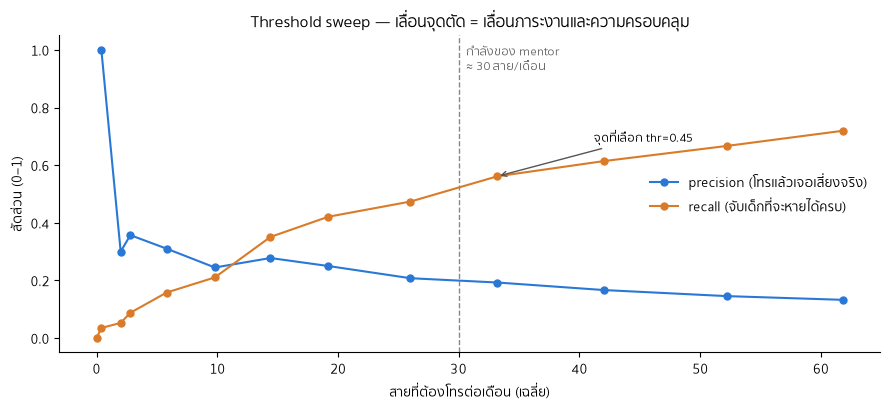

In [23]:
# checkpoint + ภาพ: เส้นโค้งการแลกเปลี่ยน — แกนนอนคือ "ภาระงานจริงของ mentor"
sweep_ok_rows = []
for thr in np.round(np.arange(0.30, 0.91, 0.05), 2):
    flag = oof69["p_model"] >= thr
    n_flag = int(flag.sum())
    sweep_ok_rows.append({
        "threshold": thr, "calls_per_month": n_flag / oof69["month"].nunique(),
        "precision": oof69.loc[flag, "y_true"].mean() if n_flag else np.nan,
        "recall": oof69.loc[flag, "y_true"].sum() / oof69["y_true"].sum()})
sweep_ok = pd.DataFrame(sweep_ok_rows)
op_ok = sweep_ok.iloc[(sweep_ok["calls_per_month"] - 30).abs().argmin()]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(sweep_ok["calls_per_month"], sweep_ok["precision"], "-o", color="#2a78d6",
        label="precision (โทรแล้วเจอเสี่ยงจริง)", markersize=5)
ax.plot(sweep_ok["calls_per_month"], sweep_ok["recall"], "-o", color="#d97b29",
        label="recall (จับเด็กที่จะหายได้ครบ)", markersize=5)
ax.axvline(30, color="#888888", ls="--", lw=1)
ax.text(30.6, 0.93, "กำลังของ mentor\n≈ 30 สาย/เดือน", fontsize=9, color="#666666")
ax.annotate(f"จุดที่เลือก thr={op_ok['threshold']:.2f}",
            xy=(op_ok["calls_per_month"], op_ok["recall"]),
            xytext=(op_ok["calls_per_month"] + 8, op_ok["recall"] + 0.12),
            arrowprops=dict(arrowstyle="->", color="#555555"), fontsize=9)
ax.set_xlabel("สายที่ต้องโทรต่อเดือน (เฉลี่ย)")
ax.set_ylabel("สัดส่วน (0–1)")
ax.set_title("Threshold sweep — เลื่อนจุดตัด = เลื่อนภาระงานและความครอบคลุม")
ax.legend(frameon=False, loc="center right")
plt.tight_layout(); plt.show()

**อ่าน trade-off ที่จุดเลือก (threshold ≈ 0.45, ~33 สาย/เดือน):**

- **precision ~0.19** — โทร 100 สาย เจอเด็กที่จะหายจริง ~19 สาย ฟังดูน้อย?
  เทียบฐานก่อนครับ: สุ่มโทรมั่วเจอแค่ ~10 สาย — โมเดลทำให้ทุกสายของ mentor
  **คุ้มขึ้นเกือบเท่าตัว** และอีก 81 สายก็ไม่ใช่สายเสียเปล่า: เป็นการทัก
  เช็คอินเด็กที่สัญญาณเริ่มตก ผู้ปกครองได้ยินว่า "สถาบันเห็นลูกฉันอยู่นะ" — นี่คือ
  ตัว retention เองแหละครับ
- **recall ~0.56** — จับเด็กที่จะหายได้เกินครึ่ง ก่อนหน้านี้เราจับได้เฉพาะที่
  บังเอิญสังเกตเห็น อีก ~44% ที่หลุด คือการบ้านของ data ปีหน้า ไม่ใช่ความล้มเหลว
- ถ้าเดือนไหน mentor งานล้น → ขยับ threshold ขึ้น ลิสต์สั้นลงแต่แม่นขึ้น —
  **ปุ่มปรับนี้เป็นของทีม ไม่ใช่ของโมเดล** และตอนนี้คุณรู้แล้วว่าปรับแล้วเสียอะไร

## [แนวคิด] 6.5 Label ก็โกหกได้ — sensitivity check ก่อนเชื่อสุดใจ

คะแนนทั้งหมดที่วัดมา ตั้งอยู่บนสมมติฐานเงียบๆ ข้อหนึ่ง: **label ถูกทุกแถว**
แต่บท 01 เราก็รู้กันอยู่ว่า label ปี 68 บางส่วนมาจากความทรงจำ + แชท LINE เก่า
(ระบบ Eduwise ทับประวัติการยกเลิก) — ตาราง `enrollment_events` เลยมีคอลัมน์
`confidence` ติดมาทุก event: `high` = มีหลักฐานชัด, `medium`/`low` = คนกรอกเองก็ไม่ชัวร์

คำถามที่คนทำ data ที่ดีต้องถามตัวเอง: *"ถ้า label กลุ่มไม่ชัวร์ผิดจริง
ข้อสรุปของเราพังไหม?"* วิธีตอบเรียกว่า **sensitivity check** — ง่ายมาก:
**ตัดเด็กที่ label ไม่ชัวร์ออกทั้งคน แล้ววัดซ้ำ** เทียบสองตัวเลข:

- ต่างกันนิดเดียว → ข้อสรุปแข็งแรง เดินหน้าต่อได้
- ต่างกันจนเวอร์ชันหนึ่งบอก "ใช้ได้" อีกเวอร์ชันบอก "แย่กว่าเดามั่ว" →
  ปัญหาเราไม่ใช่โมเดล แต่คือ**คุณภาพ label** — ต้องกลับไปเก็บข้อมูลก่อน

In [24]:
# ตัวอย่าง (เคสคู่ขนาน): สำรวจก่อนว่า label ไม่ชัวร์มีเยอะแค่ไหน
events = pd.read_csv(DATA_DIR / "enrollment_events.csv", parse_dates=["event_date"])
print("confidence ทุก event:", events["confidence"].value_counts().to_dict())
print("เฉพาะ event ยกเลิก  :",
      events.loc[events["event_type"] == "cancel", "confidence"].value_counts().to_dict())
events[events["confidence"] != "high"].head(3)

confidence ทุก event: {'high': 411, 'medium': 25}
เฉพาะ event ยกเลิก  : {'high': 101, 'medium': 25}


,student_key,year,event_type,event_date,event_month,subject_ids,source,confidence
167,2568-1023,2568,cancel,2025-06-30,2025-06,1;4,label_sheet,medium
168,2568-1024,2568,cancel,2025-07-31,2025-07,1;6,memory,medium
180,2568-1060,2568,cancel,2025-08-31,2025-08,1;5,label_sheet,medium


### [แบบฝึกหัด 6.5] วัดซ้ำโดยไม่มีเด็กกลุ่ม label ไม่ชัวร์

**คำสั่ง:**
1. สร้าง set ชื่อ `shaky` — `student_key` ของนักเรียนที่**มี event ใดก็ตาม**
   ที่ `confidence` เป็น `medium` หรือ `low`
2. กรอง `oof69` เอาเด็กกลุ่มนั้นออก (ออก**ทั้งคน** ทุกแถวของเขา)
3. ประกอบ dict ชื่อ `sensitivity` 3 ช่อง:
   - `"ap_all"` — AP ของ `p_model` บน `oof69` เต็มๆ (เท่าที่วัดไปแล้ว)
   - `"ap_high_conf"` — AP บนก้อนที่กรองแล้ว
   - `"n_dropped_rows"` — จำนวนแถวที่หายไปจากการกรอง

**ผลลัพธ์ที่คาด:** ตัดออกราวๆ 38 แถว (นักเรียนปี 69 จำนวน 12 คน
จาก shaky ทั้งหมด 25 คนสองซีซัน) — แล้ว AP สองเวอร์ชันต่างกันแค่ทศนิยมตำแหน่งที่สอง

In [25]:
ev = pd.read_csv(DATA_DIR / "enrollment_events.csv")

# ① รายชื่อเด็กที่มี event ใดก็ตามเป็น medium/low (set = รายชื่อไม่ซ้ำ)
shaky = set(ev.loc[ev["confidence"].isin(["medium", "low"]), "student_key"])

# ② ธง "อยู่ในบัญชีไม่ชัวร์" แล้วกลับธงเพื่อเก็บเฉพาะคนชัวร์ (ท่า ~isin ที่เพิ่งเรียน!)
keep = ~oof69["student_key"].isin(shaky)

# ③ วัดซ้ำสองเวอร์ชันเทียบกัน
sensitivity = {
    "ap_all":        average_precision_score(oof69["y_true"], oof69["p_model"]),
    "ap_high_conf":  average_precision_score(oof69.loc[keep, "y_true"], oof69.loc[keep, "p_model"]),
    "n_dropped_rows": int((~keep).sum()),
}
print(sensitivity)
checks.check("ex_06_05", sensitivity)


{'ap_all': 0.24451964341071028, 'ap_high_conf': 0.2283996019702051, 'n_dropped_rows': 38}
ผ่าน ✓  (ex_06_05) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

สามขั้นตรงตามคำสั่งเลย: (1) กรองตาราง event เอาเฉพาะแถวที่ confidence
เป็น medium หรือ low แล้วห่อคอลัมน์รหัสนักเรียนให้กลายเป็น set
(2) กรอง OOF ปี 69 ด้วยเงื่อนไขนิเสธ — เก็บไว้เฉพาะคนที่*ไม่*อยู่ใน set นั้น
(3) วัด AP สองรอบ รอบแรกก้อนเต็ม รอบสองก้อนที่กรองแล้ว
· จำนวนแถวที่หาย = ขนาดสองก้อนลบกันตรงๆ

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- กรอง confidence: `.isin(["medium", "low"])` · ห่อคอลัมน์: `set(...)`
- เงื่อนไขนิเสธ: `~` นำหน้า `.isin(...)`
- `average_precision_score(...)` สองรอบ
- นับแถวที่หาย: `len(...)` ลบกัน

</details>

In [26]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_06_05.py

**อ่านผล:** AP ขยับจาก ~0.245 → ~0.228 — ขยับนิดเดียวและ**ข้อสรุปไม่พลิก**
(ยังชนะเดามั่วชัดเจน ยังเป็นโมเดลตัวเดิมที่เราเลือก) ถือว่าสอบผ่าน sensitivity ✅

แต่สังเกตอีกมุมครับ: ใน 57 churns ของปี 69 มีถึง ~10 ครั้งที่อยู่ในกลุ่ม label
ไม่ชัวร์ — เกือบ 1 ใน 5! นี่คือเหตุผลที่**การบ้านจากบท 01 (กรอก label sheet
ทุกสิ้นเดือน ตอนที่ยังจำได้)** สำคัญกว่าการอัปเกรดโมเดลใดๆ ปีหน้า label สะอาดขึ้น
→ CI แคบลง → ตัดสินใจกล้าขึ้น — ห่วงโซ่นี้เริ่มที่วินัยการจดของทีมเราเอง

## GATE ก่อน deploy — เกณฑ์ที่ตกลงกันไว้ (จาก README ตั้งแต่วันแรก)

> **"ดีพอ deploy" = precision@30 บนเดือน holdout ปี 69 ต้อง ≥ tier heuristic
> (ระบบแดง/ส้ม ที่ mentor ใช้อยู่ปัจจุบัน)**

ยุติธรรมดีครับ: โมเดลไม่ได้แข่งกับความสมบูรณ์แบบ มันแข่งกับ**ของที่ทีมใช้อยู่จริง**
ถ้าไม่ชนะของเดิม ก็ไม่มีเหตุผลต้อง maintain ของใหม่ — cell ล่างวัดแบบเดือนต่อเดือน
บน OOF ปี 69 ทั้ง 5 เดือน (ทุกเดือนคือคำทำนายจากโมเดลที่ไม่เคยเห็นเดือนนั้น)

In [27]:
# ── GATE: precision@30 รายเดือนปี 69 — โมเดล (OOF) vs tier heuristic ──
stub = oof69[["student_key", "month"]].copy()
stub["year"] = 2569
oof69["tier_score"] = churn_utils.tier_baseline_score(stub, weekly).values

gate_rows = []
for m, g in oof69.groupby("month"):
    gate_rows.append({"month": m, "active": len(g), "churns": int(g["y_true"].sum()),
                      "p30_model": churn_utils.precision_at_k(g["y_true"], g["p_model"], 30),
                      "p30_tier": churn_utils.precision_at_k(g["y_true"], g["tier_score"], 30)})
gate = pd.DataFrame(gate_rows)

ap_oof_69 = average_precision_score(oof69["y_true"], oof69["p_model"])
p30_model_69 = gate["p30_model"].mean()
p30_tier_69 = gate["p30_tier"].mean()

print(gate.round(3).to_string(index=False))
verdict = "ผ่าน ✓ — deploy ได้" if p30_model_69 >= p30_tier_69 else "ไม่ผ่าน ✗ — ใช้ tier ต่อ + เก็บข้อมูลรอปีหน้า"
print(f"\nค่าเฉลี่ย 5 เดือน: โมเดล {p30_model_69:.3f} vs tier {p30_tier_69:.3f}"
      f"  →  GATE {verdict}")
print("(สังเกต พ.ค. 69: tier ชนะโมเดลอยู่เดือนเดียว — ของจริงมันสูสีแบบนี้แหละครับ "
      "เราตัดสินที่ค่าเฉลี่ย ไม่ใช่เดือนที่ถูกใจ)")

  month  active  churns  p30_model  p30_tier
2026-03     108      13      0.200     0.167
2026-04     124      13      0.233     0.167
2026-05     119      11      0.200     0.233
2026-06     113       7      0.133     0.100
2026-07     106      13      0.233     0.167

ค่าเฉลี่ย 5 เดือน: โมเดล 0.200 vs tier 0.167  →  GATE ผ่าน ✓ — deploy ได้
(สังเกต พ.ค. 69: tier ชนะโมเดลอยู่เดือนเดียว — ของจริงมันสูสีแบบนี้แหละครับ เราตัดสินที่ค่าเฉลี่ย ไม่ใช่เดือนที่ถูกใจ)


## [แนวคิด] 6.6 เซฟผู้ชนะลงกล่อง — ให้บท 07–08 หยิบไปใช้ได้เลย

GATE ผ่านแล้ว 🎉 ขั้นสุดท้ายของบทนี้คือ fit **โมเดลตัวจริง** แล้วเก็บลงไฟล์
สองการตัดสินใจสำคัญ:

1. **train ด้วยข้อมูลถึงเดือนไหน?** — ทุกเดือนที่มี label ถึง `2026-06`
   (เดือน `2026-07` เว้นไว้เป็นเดือน holdout สุดท้ายที่โมเดลไม่เคยเห็น —
   บท 08 จะ replay เดือนนี้ตอนซ้อม deploy)
2. **เซฟอะไรบ้าง?** — ไม่ใช่แค่ตัวโมเดล แต่เป็น **bundle** dict 4 ช่อง:

| key | เก็บอะไร | ทำไมต้องมี |
|---|---|---|
| `pipeline` | โมเดล + preprocessing ทั้งเส้น | ตอน serve เรียก `predict_proba` ได้เลย ไม่ต้องประกอบใหม่ |
| `features` | `{"numeric": [...], "categorical": [...]}` | บท 08 อ่านรายชื่อคอลัมน์จากกล่อง — **serve ใช้ชุดเดียวกับ train เสมอ** ไม่มีเดา |
| `trained_through` | `"2026-06"` | รู้ทันทีว่าโมเดลนี้เห็นข้อมูลถึงไหน (สำคัญมากตอน debug) |
| `metrics` | คะแนน ณ วันเซฟ | อีก 6 เดือนเปิดกล่องมาดู จะได้รู้ว่าตอนนั้นมันเก่งแค่ไหน |

เครื่องมือเซฟคือ `joblib` — ตัว pickle ที่ถนัดของ sklearn

In [28]:
# ตัวอย่าง (เคสคู่ขนาน): joblib เซฟ/โหลด dict อะไรก็ได้ — ลองกับกล่องของเล่นก่อน
import joblib
from src.config import MODELS_DIR

MODELS_DIR.mkdir(exist_ok=True)
demo_path = MODELS_DIR / "_demo_box.joblib"

joblib.dump({"note": "อะไรที่ pickle ได้ ก็ใส่กล่องได้", "numbers": [1, 2, 3]}, demo_path)
back = joblib.load(demo_path)
print("เปิดกล่องกลับมา:", back)
print("ครบทุก key:", set(back) == {"note", "numbers"})
demo_path.unlink()   # เก็บกวาดกล่องของเล่น — กล่องจริงอยู่แบบฝึกหัดล่าง

เปิดกล่องกลับมา: {'note': 'อะไรที่ pickle ได้ ก็ใส่กล่องได้', 'numbers': [1, 2, 3]}
ครบทุก key: True


### [แบบฝึกหัด 6.6] Fit โมเดลสุดท้าย + เซฟ bundle ลง models/churn_model.joblib

**คำสั่ง:**
1. `train_final` — แถวของ `labeled` ที่ `month <= "2026-06"` (ควรได้ 1,227 แถว)
2. `final_pipe` — `make_logreg()` (ผู้ชนะ) fit ด้วย `train_final[X_COLS]` กับ label
3. ประกอบ dict ชื่อ `bundle` 4 ช่องตามตารางข้างบนเป๊ะ:
   - `"pipeline"`: `final_pipe`
   - `"features"`: `{"numeric": churn_utils.NUMERIC_FEATURES, "categorical": churn_utils.CATEGORICAL_FEATURES}`
   - `"trained_through"`: `"2026-06"`
   - `"metrics"`: dict ใส่ `ap_oof_2569`, `p30_oof_2569`, `p30_tier_2569`
     (ตัวเลขจาก cell GATE — แปลงเป็น `float(...)` ให้เรียบร้อย)
4. `joblib.dump(bundle, MODELS_DIR / "churn_model.joblib")`

**ผลลัพธ์ที่คาด:** ไฟล์ `models/churn_model.joblib` โผล่ในโปรเจกต์ —
เครื่องตรวจจะ**โหลดกลับมาลอง predict จริง** เพราะบท 07–08 ต้องพึ่งไฟล์นี้

In [29]:
for name in ["labeled", "X_COLS", "make_logreg", "oof69",
             "ap_oof_69", "p30_model_69", "p30_tier_69"]:
    print(f"{name:15s}", "✓ มีแล้ว" if name in globals() else "✗ ยังไม่มี — cell ที่สร้างมันยังไม่ได้รัน")


labeled         ✓ มีแล้ว
X_COLS          ✓ มีแล้ว
make_logreg     ✓ มีแล้ว
oof69           ✓ มีแล้ว
ap_oof_69       ✓ มีแล้ว
p30_model_69    ✓ มีแล้ว
p30_tier_69     ✓ มีแล้ว


In [30]:
import joblib
from src.config import MODELS_DIR

train_final = labeled[labeled["month"] <= "2026-06"]
print("train_final:", len(train_final), "แถว | churn", int(train_final["churned_next_month"].sum()), "เคส")
final_pipe = make_logreg().fit(train_final[X_COLS], train_final["churned_next_month"])
bundle = {"pipeline": final_pipe,
          "features": {"numeric": churn_utils.NUMERIC_FEATURES, "categorical": churn_utils.CATEGORICAL_FEATURES},
          "trained_through": "2026-06",
          "metrics": {"ap_oof_2569": float(ap_oof_69),
                      "p30_oof_2569": float(p30_model_69),
                      "p30_tier_2569": float(p30_tier_69)}}
joblib.dump(bundle, MODELS_DIR / "churn_model.joblib")
print("เซฟแล้ว:", MODELS_DIR / "churn_model.joblib")
checks.check("ex_06_06", bundle)


train_final: 1227 แถว | churn 104 เคส
เซฟแล้ว: /Users/sakkarin/Desktop/Claude code/ml-churn-portfolio/models/churn_model.joblib
ผ่าน ✓  (ex_06_06) เยี่ยมมากครับ 🎉


True

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

สี่ขั้นตรงตามคำสั่ง ไม่มีทริค: กรองเดือนด้วยเงื่อนไข string (รูปแบบ YYYY-MM
เทียบน้อยกว่าหรือเท่ากับได้ตรงๆ เพราะเรียงตามตัวอักษรเท่ากับเรียงตามเวลา)
→ fit ด้วยโรงงานผู้ชนะเหมือนที่ทำมาทั้งบท → dict ก็พิมพ์ตาม spec ช่องต่อช่อง
(ชื่อ key ต้องเป๊ะ เพราะบท 08 เปิดกล่องตามชื่อพวกนี้) → ปิดจ๊อบด้วยการ dump
ลงไฟล์ตาม path ที่โจทย์กำหนด

</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- กรองเดือน: เทียบ string ด้วย `<= "2026-06"`
- `make_logreg()` ต่อด้วย `.fit(...)`
- ตัวเลขใน metrics: ห่อด้วย `float(...)` ให้เรียบร้อย
- `joblib.dump(..., MODELS_DIR / "churn_model.joblib")`

</details>

In [31]:
# %load ../solutions/sol_06_06.py
# เฉลย 6.6 — fit ผู้ชนะบนข้อมูล ≤ 2026-06 แล้วเซฟเป็น bundle ให้บท 07–08 ใช้ต่อ
train_final = labeled[labeled["month"] <= "2026-06"]       # เว้น 2026-07 ไว้เป็น holdout
final_pipe = make_logreg().fit(train_final[X_COLS],
                               train_final["churned_next_month"])

bundle = {
    "pipeline": final_pipe,
    "features": {"numeric": churn_utils.NUMERIC_FEATURES,
                 "categorical": churn_utils.CATEGORICAL_FEATURES},
    "trained_through": "2026-06",
    "metrics": {"ap_oof_2569": float(ap_oof_69),
                "p30_oof_2569": float(p30_model_69),
                "p30_tier_2569": float(p30_tier_69)},
}

MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(bundle, MODELS_DIR / "churn_model.joblib")

print(f"fit ด้วย {len(train_final):,} แถว (ถึงเดือน {bundle['trained_through']})")
print("เซฟแล้ว:", MODELS_DIR / "churn_model.joblib")
print("เปิดกล่องเช็ค:", sorted(joblib.load(MODELS_DIR / "churn_model.joblib")))
checks.check("ex_06_06", bundle)


fit ด้วย 1,227 แถว (ถึงเดือน 2026-06)
เซฟแล้ว: /Users/sakkarin/Desktop/Claude code/ml-churn-portfolio/models/churn_model.joblib
เปิดกล่องเช็ค: ['features', 'metrics', 'pipeline', 'trained_through']
ผ่าน ✓  (ex_06_06) เยี่ยมมากครับ 🎉


True

In [32]:
# กันพลาดให้บท 07–08: เซฟเวอร์ชัน canonical ทับไว้เสมอ (เนื้อหาเดียวกับเฉลย 6.6)
train_final_ok = labeled[labeled["month"] <= "2026-06"]
final_pipe_ok = make_logreg().fit(train_final_ok[X_COLS], train_final_ok["churned_next_month"])
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump({"pipeline": final_pipe_ok,
             "features": {"numeric": churn_utils.NUMERIC_FEATURES,
                          "categorical": churn_utils.CATEGORICAL_FEATURES},
             "trained_through": "2026-06",
             "metrics": {"ap_oof_2569": float(ap_oof_69),
                         "p30_oof_2569": float(p30_model_69),
                         "p30_tier_2569": float(p30_tier_69)}},
            MODELS_DIR / "churn_model.joblib")
print(f"models/churn_model.joblib พร้อมสำหรับบท 07–08 ✓  "
      f"(train ถึง 2026-06 = {len(train_final_ok):,} แถว)")

models/churn_model.joblib พร้อมสำหรับบท 07–08 ✓  (train ถึง 2026-06 = 1,227 แถว)


## สรุปสิ่งที่ได้จากบทนี้

- **Random split โกหก**กับข้อมูลเล็ก+แถวไม่อิสระ+มีเวลา — เปลี่ยน seed คะแนนก็เปลี่ยน
  และ 97% ของ test มีเด็กคนเดิมอยู่ฝั่ง train · ยารักษาคือ **expanding window**:
  replay อดีต 9 ยก แบบเดียวกับการใช้งานจริง
- **Challenger ไม่ได้ชนะเสมอ**: HGB แพ้ LogReg (AP เฉลี่ย ~0.18–0.20 vs 0.254) —
  data เล็ก โมเดลเรียบง่ายคือเกราะ ไม่ใช่ความขี้แพ้ + ได้กับดัก **GroupKFold by student**
  ติดตัวไว้สำหรับวันที่จะ tune
- **Bootstrap CI** สอนความถ่อมตัว: AP 0.245 [0.16, 0.36] — รายงานเป็นช่วงเสมอ
  และสิ่งเดียวที่ทำให้ช่วงแคบลงคือ **label สะอาดที่เก็บเพิ่มทุกเดือน**
- **Threshold คือการตัดสินใจธุรกิจ**: จุดที่เลือก ~30 สาย/เดือน (thr ≈ 0.45)
  precision ~0.19 (เกือบ 2 เท่าของสุ่มโทร) recall ~0.56 — ปุ่มปรับอยู่ในมือทีม
- **Sensitivity check**: ตัด label ไม่ชัวร์ออกแล้วข้อสรุปไม่พลิก (0.245 → 0.228) ✅
- **GATE ผ่าน**: precision@30 เฉลี่ยปี 69 — โมเดล 0.200 ≥ tier 0.167 →
  fit ตัวจริงบนข้อมูล ≤ 2026-06 แล้วเซฟ **bundle** ลง `models/churn_model.joblib`
  (pipeline + features + trained_through + metrics) เรียบร้อย

**บทต่อไป (07):** โมเดลบอกว่า "น้องคนนี้เสี่ยง 0.72" — แต่ mentor ต้องการรู้ว่า
**"เพราะอะไร"** ถึงจะเปิดบทสนทนากับเด็กและผู้ปกครองถูก เราจะแกะสมองของ LogReg
ออกมาเป็นเหตุผลรายคนภาษาไทยกันครับ (นี่แหละโบนัสของการที่แชมป์เราเป็นโมเดลเส้นตรง 😉)